In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [6]:
X_train.shape


(60000, 28, 28)

In [7]:
X_test.shape


(10000, 28, 28)

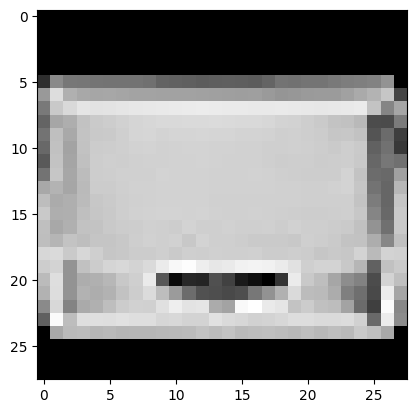

In [8]:
plt.imshow(X_train[12500], cmap='gray')

In [9]:
#class names for readable plots
class_names = ['T_shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize and reshape
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)



**Cell 3 - Visualize sample images**

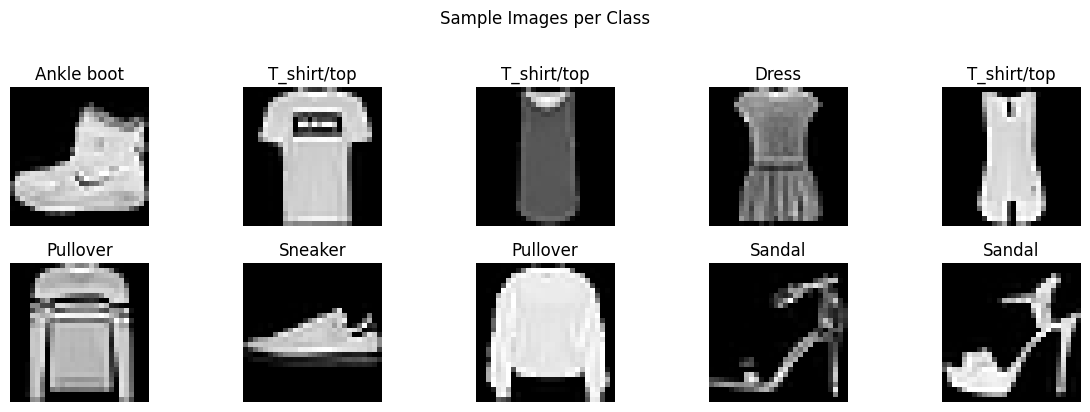

Saved to results/


In [10]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Sample Images per Class' , y = 1.02)
plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/")

**Cell 4 -- Data augmentation**

In [11]:
datagen= ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)
print("Augmentation pipeline ready")

Augmentation pipeline ready


**Cell 5 -- Build the model**

In [12]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation = "relu", padding="same", input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128,(3,3), activation= 'relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Classifier head 
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    Dense(10, activation='softmax')
])

model.compile(optimizer = 'adam',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\sohei\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 256)                 │           1,0

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)

**Cell 6 __ Train**

In [13]:
#callbacks = [
 #   EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
  #  ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
#]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test_cat),
    
)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 91s 93ms/step - accuracy: 0.7425 - loss: 0.6987 - val_accuracy: 0.8401 - val_loss: 0.4335
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 93ms/step - accuracy: 0.8263 - loss: 0.4637 - val_accuracy: 0.8699 - val_loss: 0.3536
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 88s 93ms/step - accuracy: 0.8506 - loss: 0.4055 - val_accuracy: 0.8889 - val_loss: 0.3040
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.8619 - loss: 0.3722 - val_accuracy: 0.8923 - val_loss: 0.2985
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 94ms/step - accuracy: 0.8698 - loss: 0.3518 - val_accuracy: 0.8915 - val_loss: 0.2909
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 94s 100ms/step - accuracy: 0.8760 - loss: 0.3334 - val_accuracy: 0.8976 - val_loss: 0.2747
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 92s 98ms/step - accuracy: 0.8828 - loss: 0.3184 - val_accuracy: 0.8980 - val_loss: 0.2662
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 95s 101ms/step - accuracy: 0.8846 - loss: 0.3101

**Cell 7__ Save accuracy & loss plots**

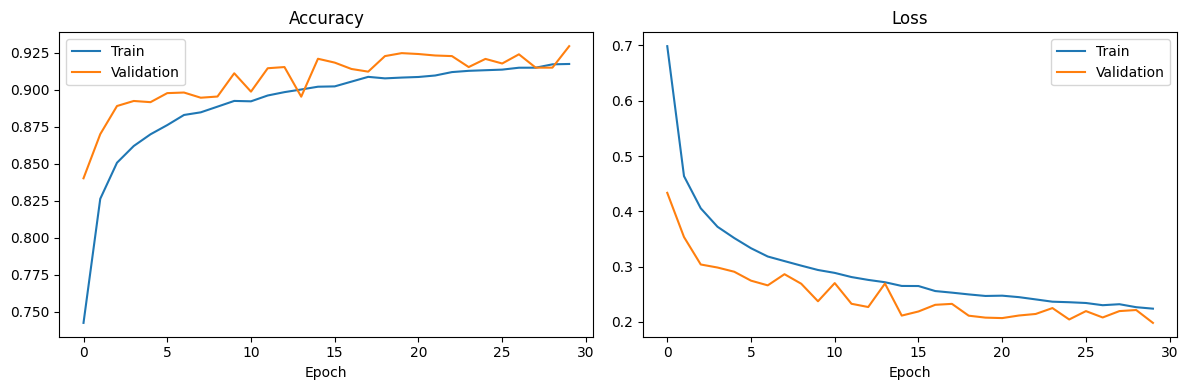

Saved to results/


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/")

**Cell 8__Evaluate & save confusion matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


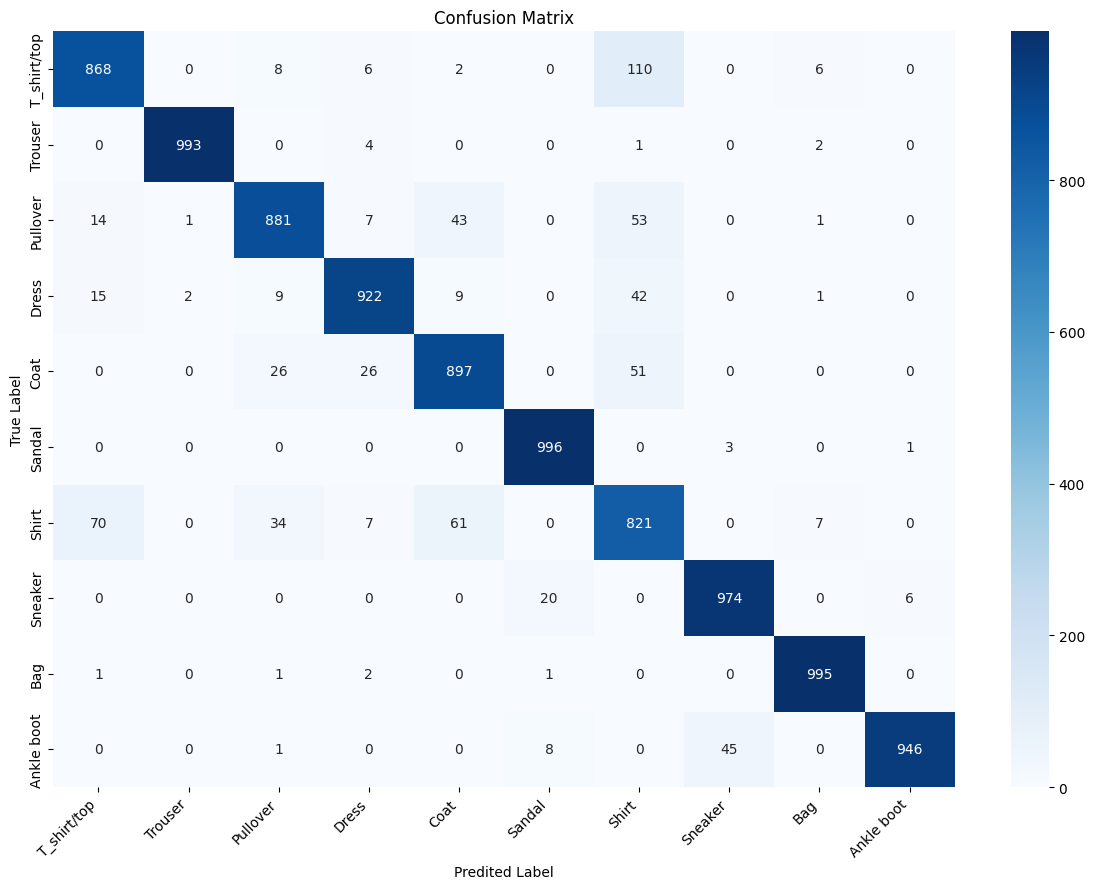


Test accuracy: 92.93%

Classification report:
              precision    recall  f1-score   support

 T_shirt/top       0.90      0.87      0.88      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.92      0.88      0.90      1000
       Dress       0.95      0.92      0.93      1000
        Coat       0.89      0.90      0.89      1000
      Sandal       0.97      1.00      0.98      1000
       Shirt       0.76      0.82      0.79      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [17]:
y_pred= model.predict(X_test)
y_pred_classes= np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predited Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

test_loss, test_acc= model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest accuracy: {test_acc*100:.2f}%")
print("\nClassification report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))

**Cell 9__Save the model**

In [19]:
model.save('../results/fashion_mnist_model.keras')
print("Model saved!")

Model saved!
